In [1]:
# Optimized DQN Experimentation Script
from itertools import product
from torch import nn
import torch.optim as optim
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback  #-------
import pandas as pd
import matplotlib.pyplot as plt
import time  #-------

2025-05-04 01:58:25.140533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-04 01:58:25.154759: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-04 01:58:25.159140: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 01:58:25.170034: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Set up environment
env = gym.make("CartPole-v1", render_mode=None)


In [3]:
# Initialize result tracking
results = []
reward_tracking = {}  #-------
loss_tracking = {}  #-------
speed_tracking = {}  #-------

# Define a callback to track rewards and losses
class RewardLossLogger(BaseCallback):  #-------
    def __init__(self, model_name, verbose=0):
        super().__init__(verbose)
        self.model_name = model_name
        self.rewards = []
        self.losses = []
        self.episode_rewards = []

    def _on_step(self) -> bool:
        if self.locals.get("dones") is not None and any(self.locals["dones"]):
            self.rewards.append(sum(self.locals["rewards"]))
        if self.model.logger.name_to_value.get("train/loss") is not None:
            self.losses.append(self.model.logger.name_to_value["train/loss"])
        return True

    def _on_training_end(self) -> None:
        reward_tracking[self.model_name] = self.rewards
        loss_tracking[self.model_name] = self.losses

In [16]:
from IPython.display import Markdown, display  #-------

def show_testing_matrix():  #-------
    matrix_md = """
### Parameters Testing Matrix

| Category              | Options                             | Count |
|-----------------------|-------------------------------------|--------|
| **Architectures**     | `[64, 64]`, `[128,128,128]`          | 2      |
| **Activations**       | `ReLU`, `Tanh`                      | 2      |
| **Optimizers**        | `Adam`, `SGD`                       | 2      |
| **Exploration Settings** | 2 dicts (`eps_init`, `eps_final`, `eps_fraction`) | 2 |
| **Replay Settings**   | 2 dicts (`learning_starts`, `train_freq`) | 2 |

**Total combinations:** `2 x 2 x 2 x 2 x 2 = 32 models`
"""
    display(Markdown(matrix_md))  #-------

show_testing_matrix()  #-------



### Parameters Testing Matrix

| Category              | Options                             | Count |
|-----------------------|-------------------------------------|--------|
| **Architectures**     | `[64, 64]`, `[128,128,128]`          | 2      |
| **Activations**       | `ReLU`, `Tanh`                      | 2      |
| **Optimizers**        | `Adam`, `SGD`                       | 2      |
| **Exploration Settings** | 2 dicts (`eps_init`, `eps_final`, `eps_fraction`) | 2 |
| **Replay Settings**   | 2 dicts (`learning_starts`, `train_freq`) | 2 |

**Total combinations:** `2 x 2 x 2 x 2 x 2 = 32 models`


In [4]:
# Define experimental hyperparameter grids
architectures = [
    [64, 64],
    [128, 128, 128]
]

activations = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh
}

optimizers = {
    "adam": optim.Adam,
    "sgd": optim.SGD
}

exploration_settings = [
    {"eps_init": 1.0, "eps_final": 0.02, "eps_fraction": 0.3},
    {"eps_init": 0.5, "eps_final": 0.05, "eps_fraction": 0.5}
]

replay_settings = [
    {"learning_starts": 1000, "train_freq": 4},
    {"learning_starts": 500, "train_freq": 1}
]

In [5]:
# Full experiment configuration grid
configs = list(product(architectures, activations.items(), optimizers.items(), exploration_settings, replay_settings))

for arch, (act_name, act_fn), (opt_name, opt_cls), eps_cfg, replay_cfg in configs:
    model_name = f"{len(arch)}x{arch[0]}_{act_name}_{opt_name}_eps{eps_cfg['eps_fraction']}_train{replay_cfg['train_freq']}"

    policy_kwargs = dict(
        net_arch=arch,
        activation_fn=act_fn,
        optimizer_class=opt_cls
    )

    model = DQN(
        "MlpPolicy",
        env,
        verbose=0,
        policy_kwargs=policy_kwargs,
        exploration_initial_eps=eps_cfg['eps_init'],
        exploration_final_eps=eps_cfg['eps_final'],
        exploration_fraction=eps_cfg['eps_fraction'],
        learning_starts=replay_cfg['learning_starts'],
        train_freq=replay_cfg['train_freq']
    )

    callback = RewardLossLogger(model_name)  #-------
    start_time = time.time()  #-------
    model.learn(total_timesteps=20000, reset_num_timesteps=True, progress_bar=False, callback=callback)  #-------
    duration = time.time() - start_time  #-------
    speed_tracking[model_name] = duration  #-------

    mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=False)
    avg_loss = sum(loss_tracking[model_name]) / len(loss_tracking[model_name]) if loss_tracking[model_name] else 0  #-------

    print(f"Trained {model_name} | Reward: {mean_reward:.2f} | Loss: {avg_loss:.4f} | Time: {duration:.2f}s")  #-------

    results.append({
        "name": model_name,
        "arch": arch,
        "activation": act_name,
        "optimizer": opt_name,
        "exploration": eps_cfg,
        "replay": replay_cfg,
        "mean_reward": mean_reward,
        "std_reward": std_reward, 
        "training_time_sec": duration  #-------
    })

    model.save(f"dqn_cartpole_{model_name}")


Trained 2x64_relu_adam_eps0.3_train4 | Reward: 9.70 | Loss: 0.0396 | Time: 23.27s
Trained 2x64_relu_adam_eps0.3_train1 | Reward: 13.90 | Loss: 0.0141 | Time: 66.73s
Trained 2x64_relu_adam_eps0.5_train4 | Reward: 9.50 | Loss: 0.0434 | Time: 26.46s
Trained 2x64_relu_adam_eps0.5_train1 | Reward: 29.70 | Loss: 0.0124 | Time: 72.29s
Trained 2x64_relu_sgd_eps0.3_train4 | Reward: 9.60 | Loss: 0.3763 | Time: 24.18s
Trained 2x64_relu_sgd_eps0.3_train1 | Reward: 9.50 | Loss: 0.2196 | Time: 66.09s
Trained 2x64_relu_sgd_eps0.5_train4 | Reward: 26.80 | Loss: 0.3901 | Time: 24.12s
Trained 2x64_relu_sgd_eps0.5_train1 | Reward: 9.60 | Loss: 0.1806 | Time: 69.66s
Trained 2x64_tanh_adam_eps0.3_train4 | Reward: 9.70 | Loss: 0.0273 | Time: 24.76s
Trained 2x64_tanh_adam_eps0.3_train1 | Reward: 9.60 | Loss: 0.0113 | Time: 68.76s
Trained 2x64_tanh_adam_eps0.5_train4 | Reward: 9.30 | Loss: 0.0322 | Time: 22.68s
Trained 2x64_tanh_adam_eps0.5_train1 | Reward: 10.00 | Loss: 0.0129 | Time: 64.14s
Trained 2x64_tan

In [6]:
# Convert to DataFrame and show results
results_df = pd.DataFrame(results)
print(results_df.sort_values("mean_reward", ascending=False))


                             name             arch activation optimizer  \
3    2x64_relu_adam_eps0.5_train1         [64, 64]       relu      adam   
6     2x64_relu_sgd_eps0.5_train4         [64, 64]       relu       sgd   
19  3x128_relu_adam_eps0.5_train1  [128, 128, 128]       relu      adam   
14    2x64_tanh_sgd_eps0.5_train4         [64, 64]       tanh       sgd   
16  3x128_relu_adam_eps0.3_train4  [128, 128, 128]       relu      adam   
1    2x64_relu_adam_eps0.3_train1         [64, 64]       relu      adam   
15    2x64_tanh_sgd_eps0.5_train1         [64, 64]       tanh       sgd   
27  3x128_tanh_adam_eps0.5_train1  [128, 128, 128]       tanh      adam   
11   2x64_tanh_adam_eps0.5_train1         [64, 64]       tanh      adam   
23   3x128_relu_sgd_eps0.5_train1  [128, 128, 128]       relu       sgd   
29   3x128_tanh_sgd_eps0.3_train1  [128, 128, 128]       tanh       sgd   
0    2x64_relu_adam_eps0.3_train4         [64, 64]       relu      adam   
8    2x64_tanh_adam_eps0.

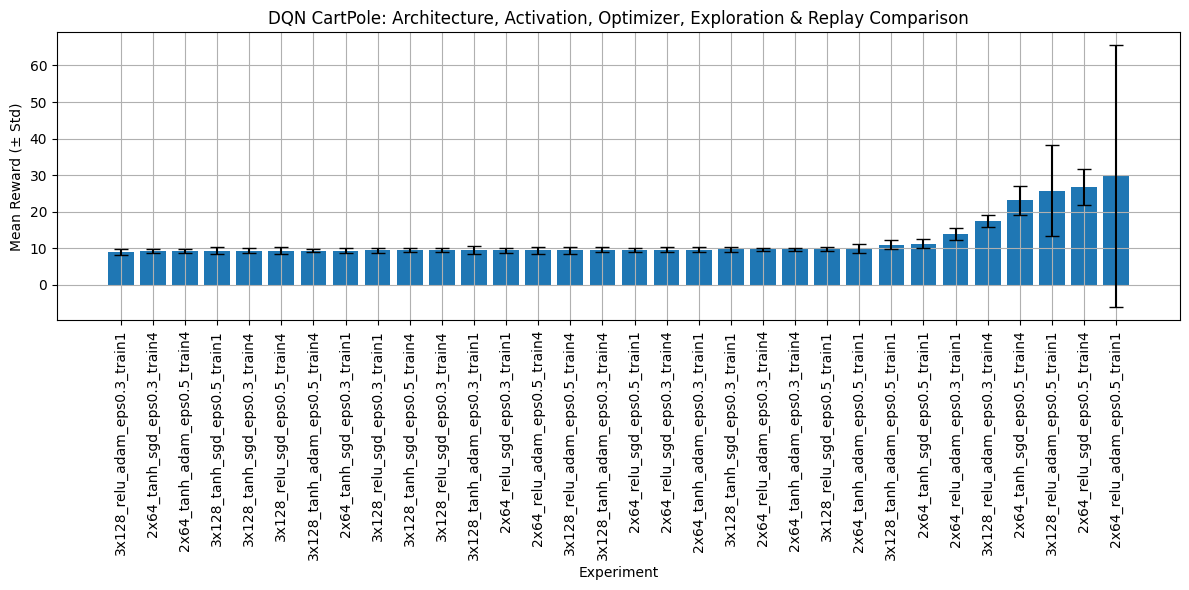

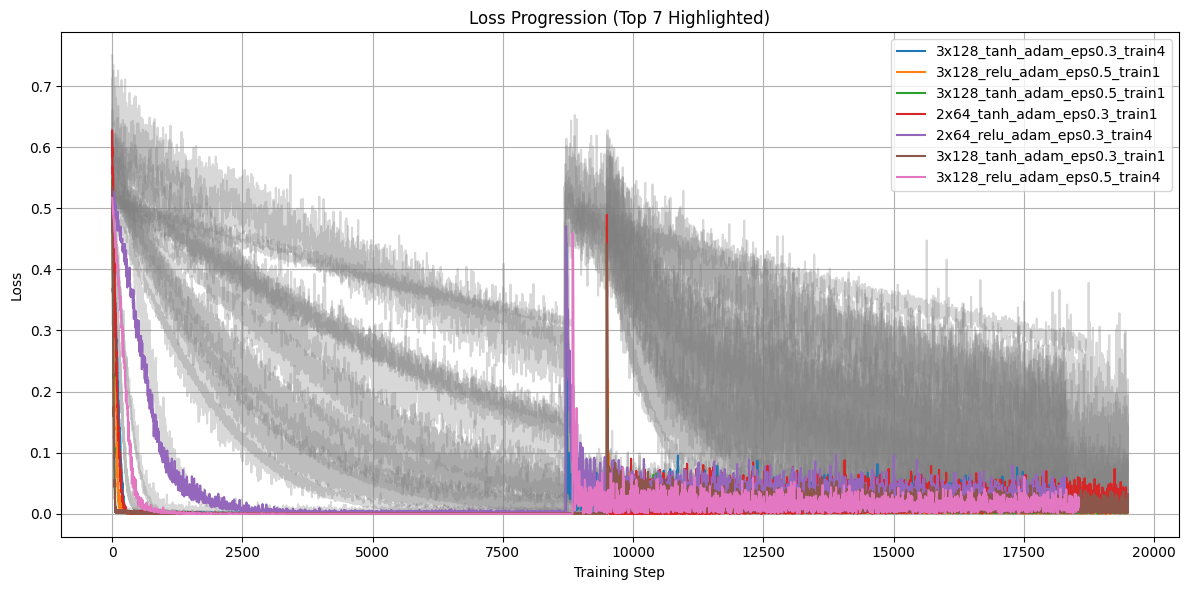

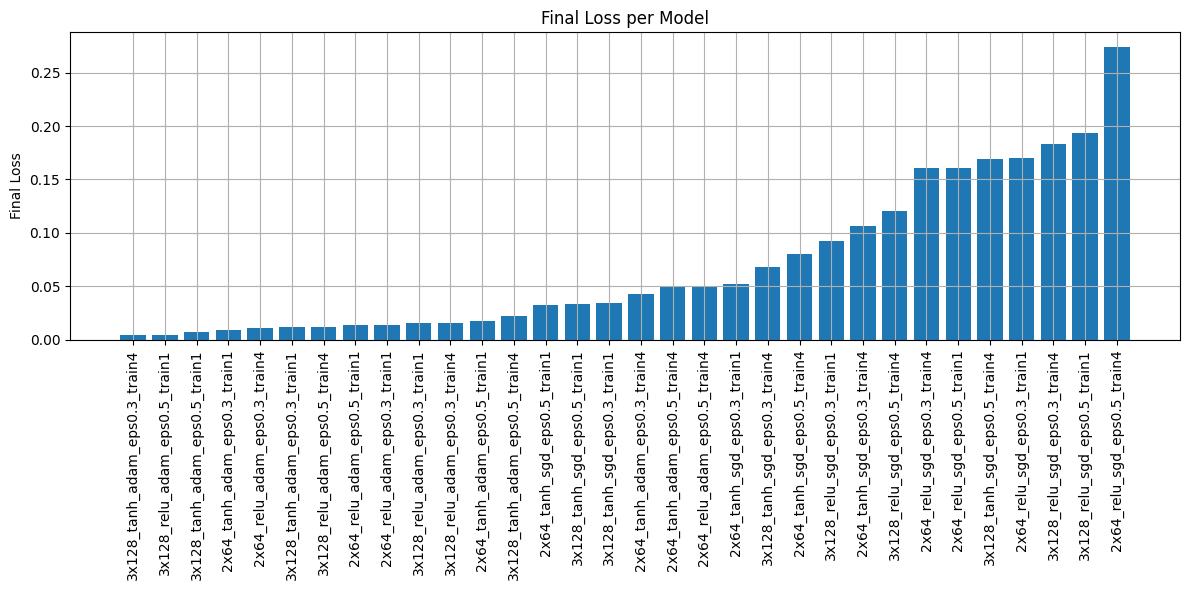

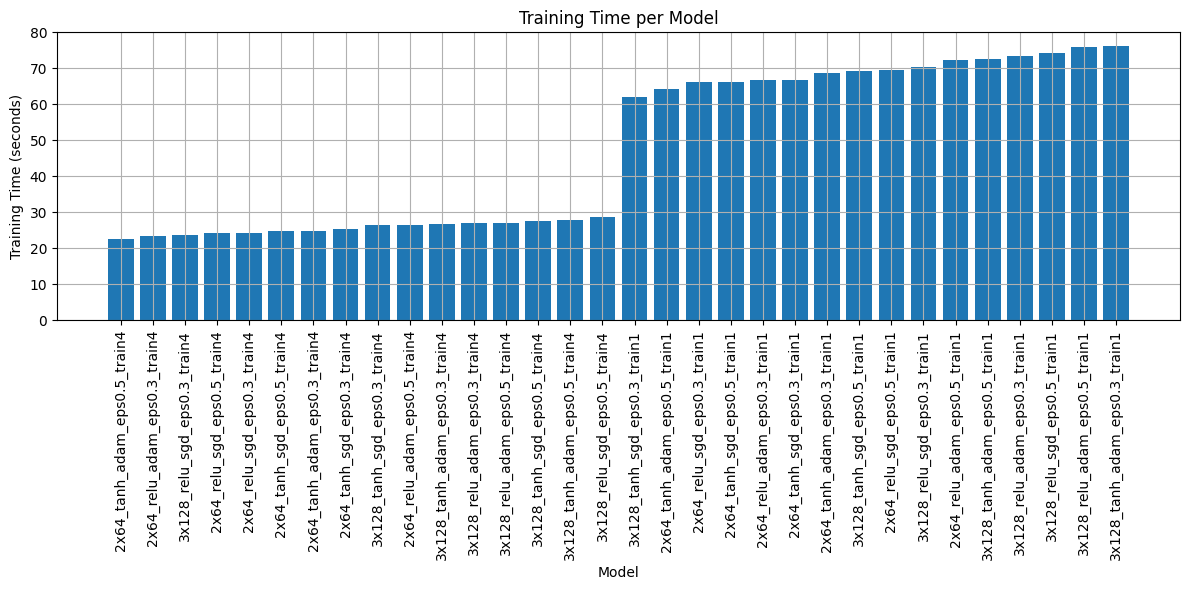

In [14]:
# Sort dataframe by mean_reward for reward bar plot
sorted_results_df = results_df.sort_values(by="mean_reward", ascending=True)

# Plot comparison of mean rewards in ascending order
plt.figure(figsize=(12, 6))
plt.bar(sorted_results_df['name'], sorted_results_df['mean_reward'], yerr=sorted_results_df['std_reward'], capsize=5)
plt.title("DQN CartPole: Architecture, Activation, Optimizer, Exploration & Replay Comparison")
plt.xlabel("Experiment")
plt.ylabel("Mean Reward (± Std)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()
"""
# Sort reward_tracking by final reward for plotting
sorted_reward_keys = sorted(reward_tracking.keys(), key=lambda k: reward_tracking[k][-1])

plt.figure(figsize=(12, 6))
for name in sorted_reward_keys:
    plt.plot(reward_tracking[name], label=name)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Progression per Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""
# Highlight Top-N and Fade the Rest
sorted_keys = sorted(loss_tracking.keys(), key=lambda k: loss_tracking[k][-1])
highlight = sorted_keys[:7]
faint = sorted_keys[7:]

plt.figure(figsize=(12, 6))
for name in faint:
    plt.plot(loss_tracking[name], color='gray', alpha=0.3)
for name in highlight:
    plt.plot(loss_tracking[name], label=name)
plt.title("Loss Progression (Top 7 Highlighted)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Sort loss_tracking by final loss for plotting
final_losses = {name: losses[-1] for name, losses in loss_tracking.items()}
sorted_items = sorted(final_losses.items(), key=lambda item: item[1])

plt.figure(figsize=(12, 6))
plt.bar([k for k, _ in sorted_items], [v for _, v in sorted_items])
plt.xticks(rotation=90)
plt.title("Final Loss per Model")
plt.ylabel("Final Loss")
plt.tight_layout()
plt.grid(True)
plt.show()

# Sort speed_tracking by value (training time)
sorted_speed_items = sorted(speed_tracking.items(), key=lambda item: item[1])
sorted_speed_keys = [item[0] for item in sorted_speed_items]
sorted_speed_values = [item[1] for item in sorted_speed_items]

plt.figure(figsize=(12, 6))
plt.bar(sorted_speed_keys, sorted_speed_values)
plt.title("Training Time per Model")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()


/tmp/ipykernel_487939/3837238081.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="name", y="mean_reward", data=results_df, capsize=0.2, ci="sd")


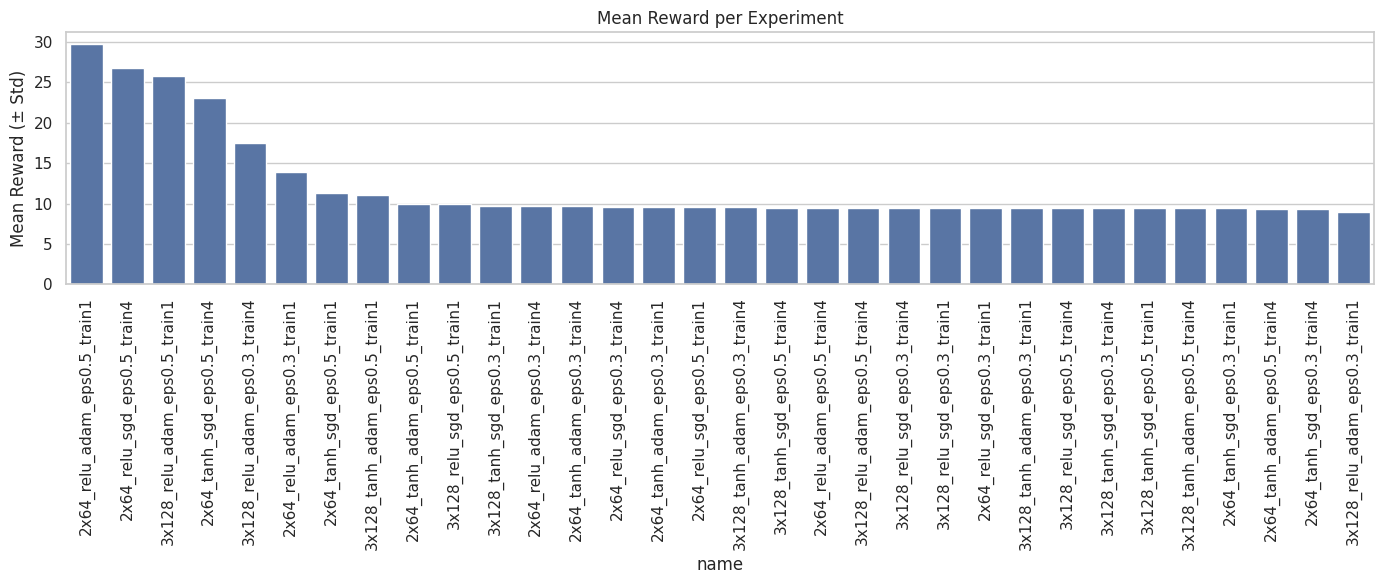

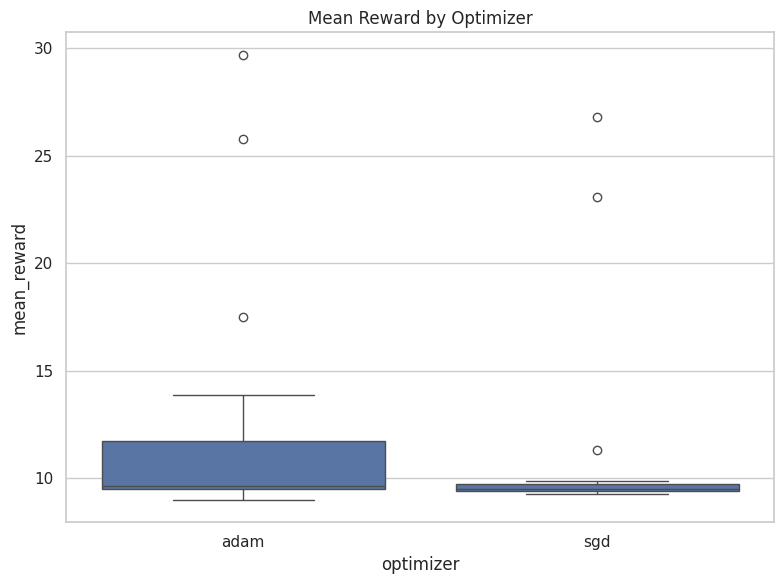

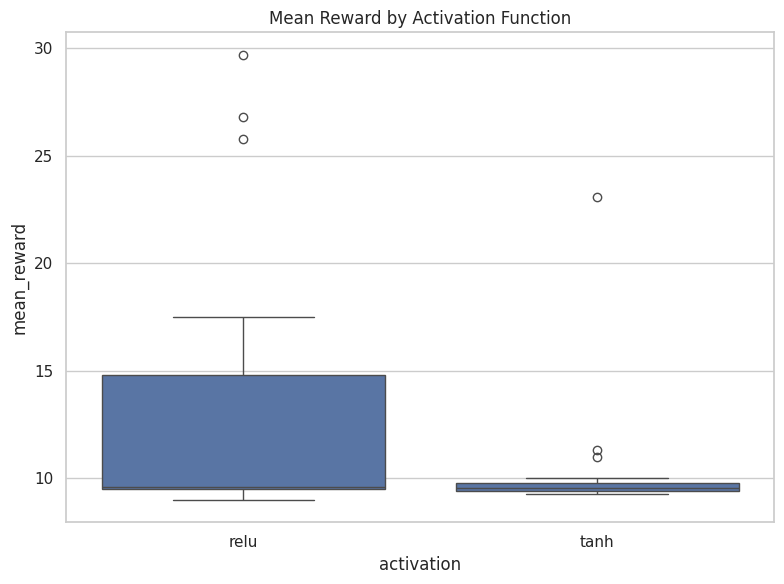

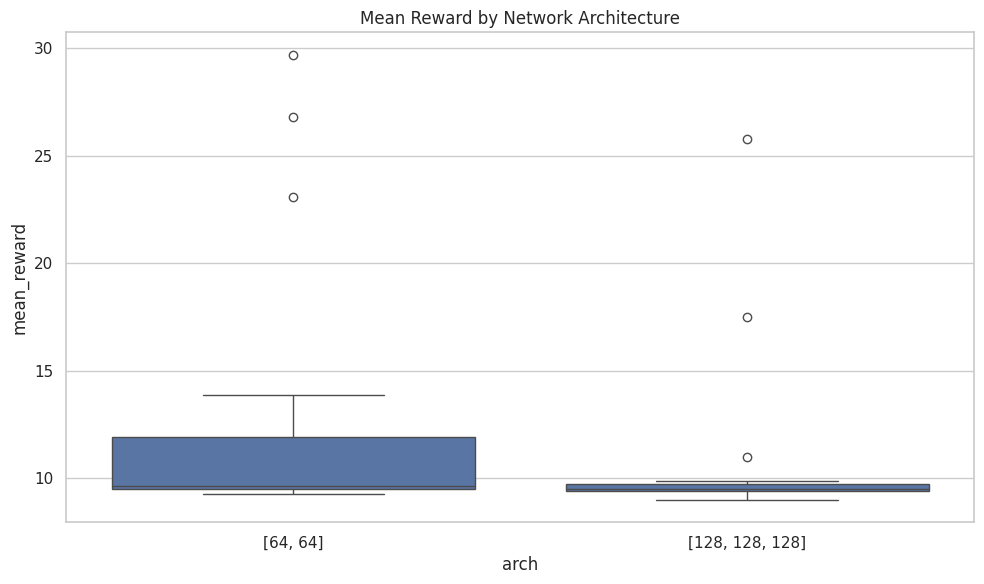

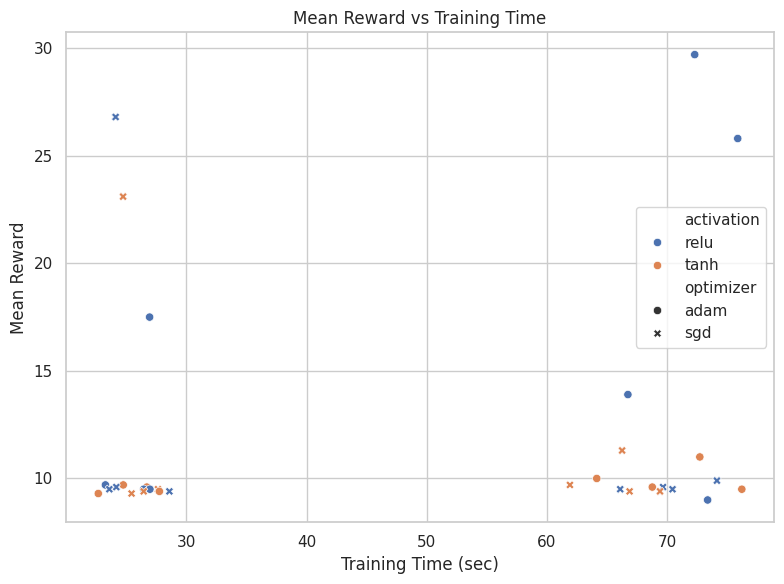

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'results' already loaded into results_df
results_df = pd.DataFrame(results)

# Sort by mean_reward
results_df = results_df.sort_values("mean_reward", ascending=False)

# Convert arch column from list to string for grouping
results_df["arch"] = results_df["arch"].apply(lambda x: str(x))

# Set seaborn style
sns.set(style="whitegrid")

# 1. Bar plot of mean_reward per model
plt.figure(figsize=(14, 6))
sns.barplot(x="name", y="mean_reward", data=results_df, capsize=0.2, ci="sd")
plt.title("Mean Reward per Experiment")
plt.xticks(rotation=90)
plt.ylabel("Mean Reward (± Std)")
plt.tight_layout()
plt.show()

# 2. Boxplot of rewards grouped by optimizer
plt.figure(figsize=(8, 6))
sns.boxplot(x="optimizer", y="mean_reward", data=results_df)
plt.title("Mean Reward by Optimizer")
plt.tight_layout()
plt.show()

# 3. Boxplot of rewards grouped by activation
plt.figure(figsize=(8, 6))
sns.boxplot(x="activation", y="mean_reward", data=results_df)
plt.title("Mean Reward by Activation Function")
plt.tight_layout()
plt.show()

# 4. Boxplot of rewards grouped by architecture
plt.figure(figsize=(10, 6))
sns.boxplot(x="arch", y="mean_reward", data=results_df)
plt.title("Mean Reward by Network Architecture")
plt.tight_layout()
plt.show()

# 5. Scatter plot: mean_reward vs training_time_sec
plt.figure(figsize=(8, 6))
sns.scatterplot(x="training_time_sec", y="mean_reward", hue="activation", style="optimizer", data=results_df)
plt.title("Mean Reward vs Training Time")
plt.xlabel("Training Time (sec)")
plt.ylabel("Mean Reward")
plt.tight_layout()
plt.show()
